In [1]:
#Imports
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table
from astropy.io import fits
import pandas as pd
import alopphot
import os

# Physical constants
h = 6.626e-34   # Planck constant [J·s]
c = 2.998e8     # Speed of light [m/s]
kB = 1.381e-23  # Boltzmann constant [J/K]
c_A = 2.998e18  # Speed of light [Angstrom/s]

# Filter definitions (central wavelength, bandwidth in Angstroms)
filters = {
    "U": (3659, 660),
    "B": (4582, 940),
    "V": (5448, 880)
}

# Distinct fancy colors for plot
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']


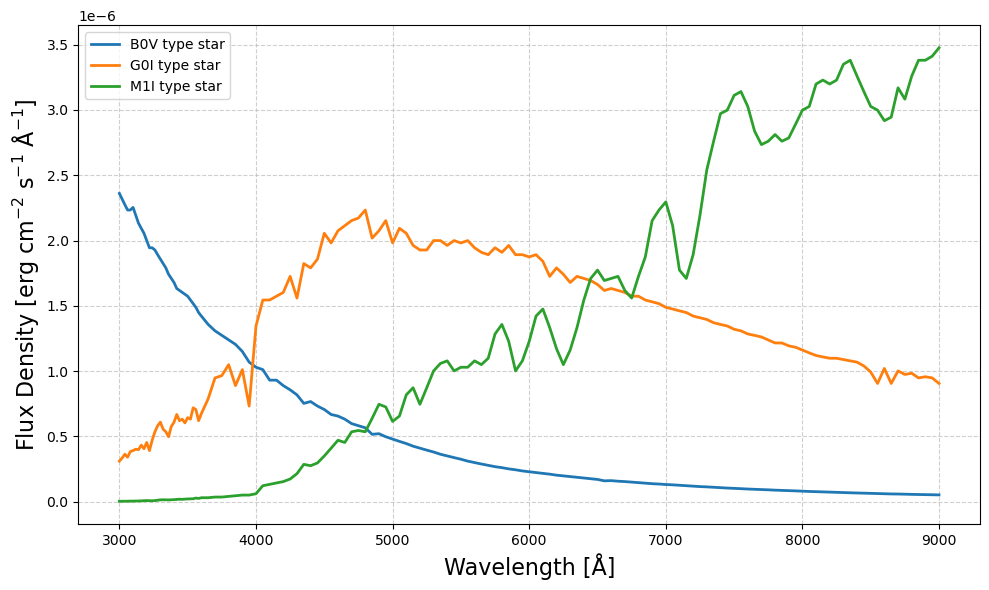

In [2]:
#Problem 1
star_info = Table.read("spectra_list.csv", format="ascii.csv")
spectral_types = {row["filename"]: row["type"] for row in star_info}
stars = ["Ab5f.csv", "Ab74f.csv", "Ab77f.csv"]


plt.figure(figsize=(10, 6))

# Plot each spectrum
for i, fname in enumerate(stars):
    d = Table.read(fname, format="ascii.csv")
    wavelength, flux = d["wavelength"], d["flux"]

    mask = (wavelength >= 3000) & (wavelength <= 9000)

    # Remove .csv extension for legend label
    label_name = os.path.splitext(fname)[0]
    
    plt.plot(wavelength[mask], flux[mask],
             label=f"{spectral_types[fname]} type star",
             color=colors[i],
             linewidth=2)

plt.xlabel("Wavelength [Å]", fontsize=16)
plt.ylabel("Flux Density [erg cm$^{-2}$ s$^{-1}$ Å$^{-1}$]", fontsize=16)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig("plot_problem_1.png")
plt.show()

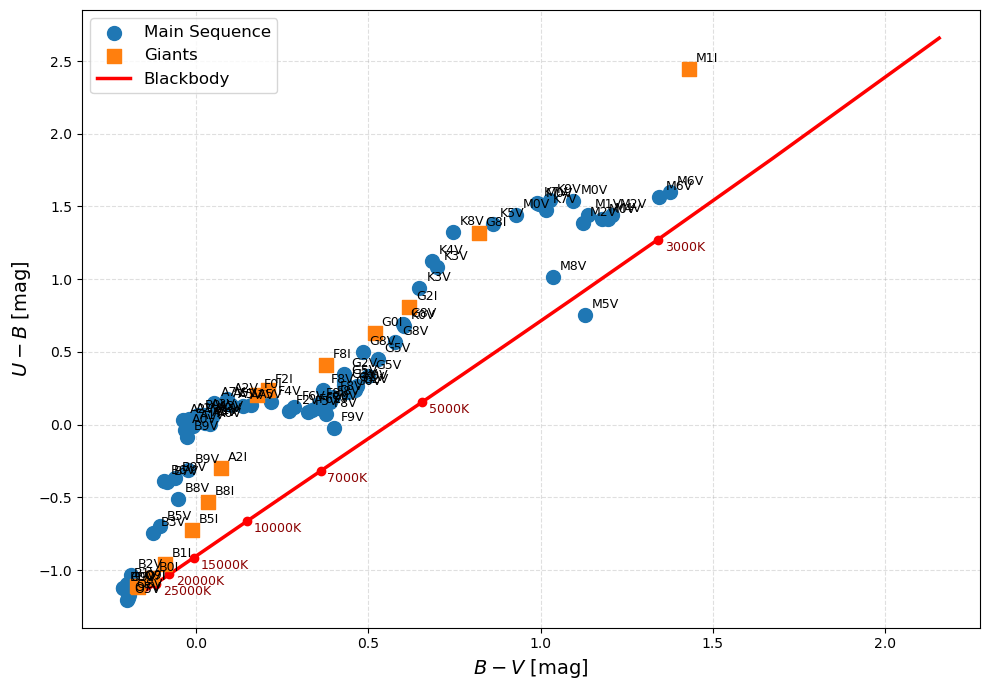

In [4]:
#Problem 3

def integrate_filter(wavelength, flux, lam0, dlam, n=100):
    lam_min = lam0 - dlam/2
    lam_max = lam0 + dlam/2
    lam = np.linspace(lam_min, lam_max, n)
    flux_interp = np.interp(lam, wavelength, flux, left=0, right=0)
    return np.trapz(flux_interp * lam, lam) / np.trapz(lam, lam)

def planck(wavelength_A, T):
    lam = wavelength_A * 1e-10  # Convert to meters
    B_lambda_SI = (2*h*c**2/lam**5) / (np.exp(h*c/(lam*kB*T)) - 1)
    # Convert from W/m^2/m/sr to erg/cm^2/s/A/sr
    B_lambda_cgs = B_lambda_SI * 1e-7 * 1e-4 * 1e10  # = 1e3
    return B_lambda_cgs

# Read Vega spectrum and convert units
vega = Table.read("vega_fnu.csv", format="ascii.csv")
vega_wavelength = vega["wavelength"] * 10.0  # nm to Angstrom
vega_flux_lambda = vega["flux"] * c_A / (vega_wavelength**2)  # F_nu to F_lambda

# Calculate Vega reference integrals
I_vega = {}
for band, (lam0, dlam) in filters.items():
    I_vega[band] = integrate_filter(vega_wavelength, vega_flux_lambda, lam0, dlam)
star_list = Table.read("spectra_list.csv", format="ascii.csv")
results = []

for row in star_list:
    spec = Table.read(row["filename"], format="ascii.csv")
    wavelength = spec["wavelength"]
    flux = spec["flux"]
    
    mags = {}
    for band, (lam0, dlam) in filters.items():
        I_star = integrate_filter(wavelength, flux, lam0, dlam)
        mags[band] = -2.5 * np.log10(I_star / I_vega[band])
    
    results.append({
        "filename": row["filename"],
        "spectral_type": row["type"],
        "U": mags["U"],
        "B": mags["B"],
        "V": mags["V"],
        "U-B": mags["U"] - mags["B"],
        "B-V": mags["B"] - mags["V"]
    })

df_stars = pd.DataFrame(results)
df_stars.to_csv("stellar_magnitudes.csv", index=False)

# Calculate blackbody colours
bb_results = []
temperatures = np.arange(2000, 30001, 500)

for T in temperatures:
    wave_bb = np.linspace(2500, 10000, 2000)
    flux_bb = planck(wave_bb, T)
    
    mags = {}
    for band, (lam0, dlam) in filters.items():
        I_bb = integrate_filter(wave_bb, flux_bb, lam0, dlam)
        mags[band] = -2.5 * np.log10(I_bb / I_vega[band])
    
    bb_results.append({
        "T": T,
        "U-B": mags["U"] - mags["B"],
        "B-V": mags["B"] - mags["V"]
    })


# Plot main sequence and giant stars
fig, ax = plt.subplots(figsize=(10, 7))
ms = [r for r in results if "V" in r["spectral_type"]]
giants = [r for r in results if "I" in r["spectral_type"]]
ax.scatter([r["B-V"] for r in ms], [r["U-B"] for r in ms], 
           s=100, marker='o', c='#1f77b4', label='Main Sequence', zorder=3)
ax.scatter([r["B-V"] for r in giants], [r["U-B"] for r in giants], 
           s=100, marker='s', c='#ff7f0e', label='Giants', zorder=3)\

# Annotate spectral types
for r in results:
    ax.annotate(r["spectral_type"], (r["B-V"], r["U-B"]), 
                xytext=(5, 5), textcoords='offset points', fontsize=9)

# Plot blackbody track
bb_bv = [r["B-V"] for r in bb_results]
bb_ub = [r["U-B"] for r in bb_results]
ax.plot(bb_bv, bb_ub, 'r-', lw=2.5, label='Blackbody', zorder=2)

# Mark temperatures
for T_mark in [3000, 5000, 7000, 10000, 15000, 20000, 25000]:
    idx = np.argmin(np.abs(temperatures - T_mark))
    ax.plot(bb_results[idx]["B-V"], bb_results[idx]["U-B"], 'ro')
    ax.annotate(f'{T_mark}K', (bb_results[idx]["B-V"], bb_results[idx]["U-B"]),
                xytext=(5, -8), textcoords='offset points', fontsize=9, color='darkred')
ax.set_xlabel(r'$B - V$ [mag]', fontsize=14)
ax.set_ylabel(r'$U - B$ [mag]', fontsize=14)
ax.grid(True, alpha=0.4, ls='--')
ax.legend(fontsize=12)
plt.tight_layout()
plt.savefig('colour_colour_diagram_problem3.png', dpi=300)
plt.show()

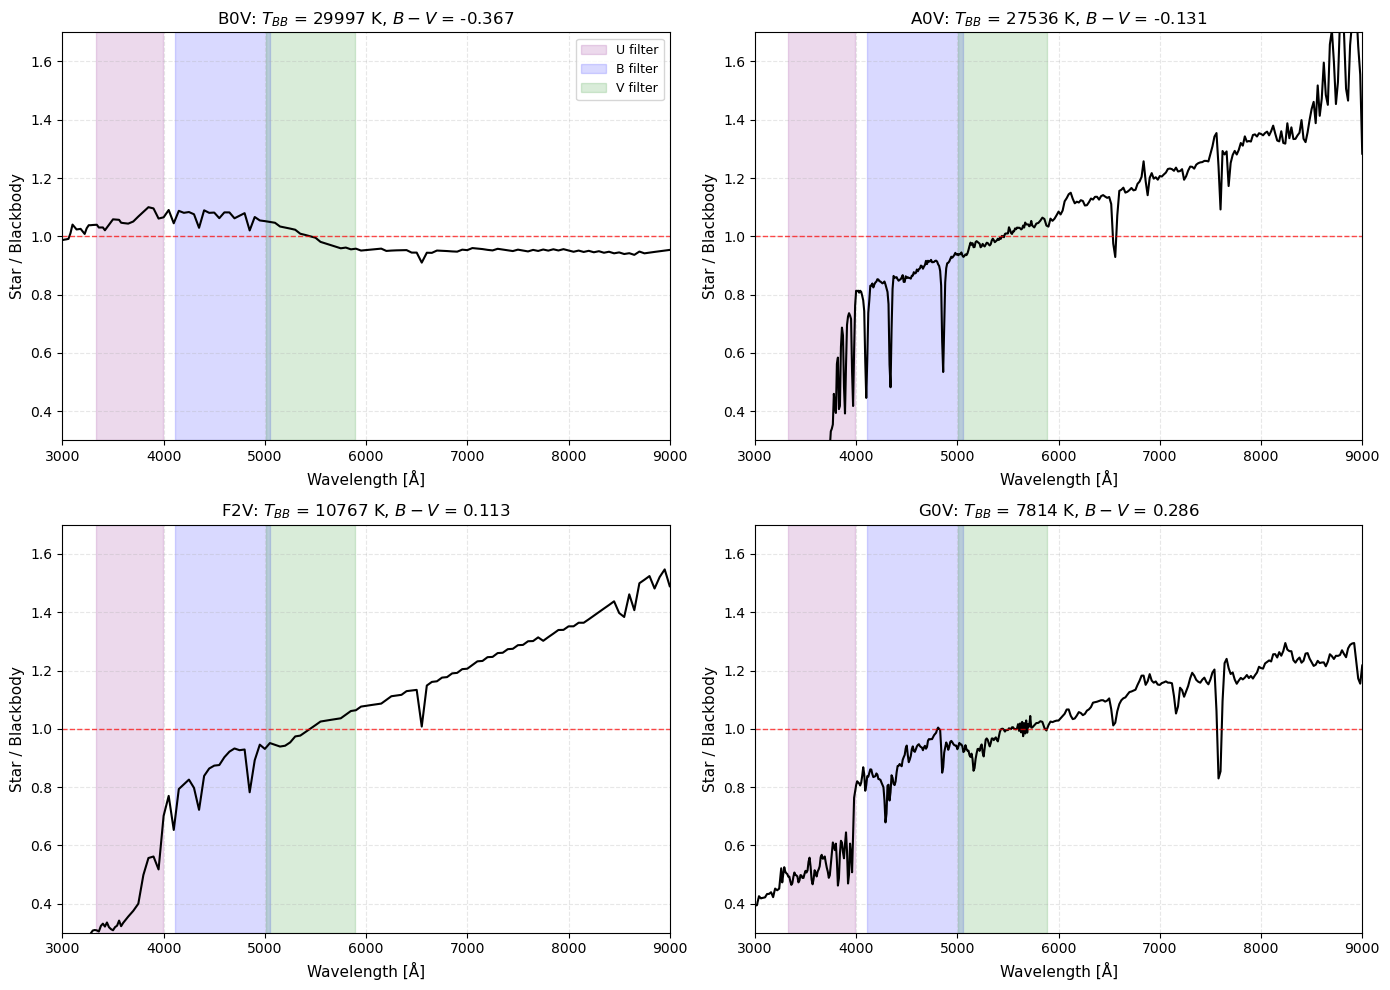


Blackbody temperatures matching stellar B-V colors:
B0V  : B-V = -0.367, T_BB = 29997 K
A0V  : B-V = -0.131, T_BB = 27536 K
F2V  : B-V =  0.113, T_BB = 10767 K
G0V  : B-V =  0.286, T_BB =  7814 K


In [5]:
#Problem 4
def calculate_bv(wave, flux, I_vega_B, I_vega_V):
    """Calculate B-V color."""
    def integrate(lam0, dlam):
        lmin, lmax = lam0 - dlam/2, lam0 + dlam/2
        lam = np.linspace(lmin, lmax, 100)
        f = np.interp(lam, wave, flux, left=0, right=0)
        return np.trapz(f * lam, lam) / np.trapz(lam, lam)
    
    I_B = integrate(*filters["B"])
    I_V = integrate(*filters["V"])
    return -2.5 * np.log10(I_B / I_vega_B) - (-2.5 * np.log10(I_V / I_vega_V))

def find_T_match(target_bv, I_vega_B, I_vega_V):
    """Find blackbody temperature matching target B-V."""
    T_min, T_max = 2000, 30000
    wave_bb = np.linspace(3000, 9000, 2000)
    
    while T_max - T_min > 10:
        T_mid = (T_min + T_max) / 2
        bv = calculate_bv(wave_bb, planck(wave_bb, T_mid), I_vega_B, I_vega_V)
        T_min, T_max = (T_min, T_mid) if bv < target_bv else (T_mid, T_max)    
    return (T_min + T_max) / 2

# Calculate Vega reference integrals
vega = Table.read("vega_fnu.csv", format="ascii.csv")
I_vega = {}
for band, (lam0, dlam) in filters.items():
    lmin, lmax = lam0 - dlam/2, lam0 + dlam/2
    lam = np.linspace(lmin, lmax, 100)
    c_A = 2.998e18  # Angstrom/s
    vega_wave = vega["wavelength"] * 10.0  # nm to Angstrom
    vega_flux_lambda = vega["flux"] * c_A / (vega_wave**2)  # F_nu to F_lambda
    f = np.interp(lam, vega_wave, vega_flux_lambda, left=0, right=0)    
    I_vega[band] = np.trapz(f * lam, lam) / np.trapz(lam, lam)

# Read stellar data from Problem 3
stellar_data = pd.read_csv("spectral_magnitudes.csv")
spectra_list = Table.read("spectra_list.csv", format="ascii.csv")
type_to_file = {row["type"]: row["filename"] for row in spectra_list}

# Analyze B0, A0, F0, G0 (use F2V if F0V unavailable)
types = ["B0V", "A0V", "F2V", "G0V"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, stype in enumerate(types):
    ax = axes[idx]
    
    # Get B-V and find matching blackbody
    bv_star = stellar_data[stellar_data["spectral_type"] == stype]["B-V"].values[0]
    T_match = find_T_match(bv_star, I_vega["B"], I_vega["V"])
    
    # Read stellar spectrum
    spec = Table.read(type_to_file[stype], format="ascii.csv")
    mask = (spec["wavelength"] >= 3000) & (spec["wavelength"] <= 9000)
    wave = spec["wavelength"][mask]
    flux_star = spec["flux"][mask]
    
    # Generate matching blackbody
    flux_bb = planck(wave, T_match)
    
    ref = 5448.0    
    flux_star_norm = flux_star / np.interp(ref, wave, flux_star)
    flux_bb_norm = flux_bb / np.interp(ref, wave, flux_bb)
    ratio = flux_star_norm / flux_bb_norm
    
    # Plot
    ax.plot(wave, ratio, 'k-', lw=1.5)
    ax.axhline(1, color='red', ls='--', lw=1, alpha=0.7)
    
    # Mark filters
    colors = {'U': 'purple', 'B': 'blue', 'V': 'green'}
    for band, (lam0, dlam) in filters.items():
        ax.axvspan(lam0 - dlam/2, lam0 + dlam/2, alpha=0.15, color=colors[band],
                  label=f'{band} filter' if idx == 0 else '')
    
    ax.set_xlabel(r'Wavelength [Å]', fontsize=11)
    ax.set_ylabel('Star / Blackbody', fontsize=11)
    ax.set_title(f'{stype}: $T_{{BB}}$ = {T_match:.0f} K, $B-V$ = {bv_star:.3f}', 
                fontsize=12)
    ax.grid(True, alpha=0.3, ls='--')
    ax.set_xlim(3000, 9000)
    ax.set_ylim(0.3, 1.7)
    if idx == 0:
        ax.legend(fontsize=9, loc='upper right')

plt.tight_layout()
plt.savefig('stellar_blackbody_comparison_problem4.png', dpi=300)
plt.show()

# Print results
print("\nBlackbody temperatures matching stellar B-V colors:")
for stype in types:
    bv = stellar_data[stellar_data["spectral_type"] == stype]["B-V"].values[0]
    T = find_T_match(bv, I_vega["B"], I_vega["V"])
    print(f"{stype:5s}: B-V = {bv:6.3f}, T_BB = {T:5.0f} K")

In [7]:
#Problem 5

# Instrument and observation parameters
gain = 5.0  # e-/ADU
readout_noise = 250.0   # electrons
aperture_radius = 5 # pixels
sky_annulus = [8, 12] # inner and outer radii

exposure_time = {"B": 30.0, "V": 10.0} # seconds
zeropoint = {"B": 16.43, "V": 17.40}# magnitudes

n_pixels = np.pi * aperture_radius**2

def calculate_magnitude_and_snr(flux_adu, sky_adu_per_pixel, exp_time, zp):
    if flux_adu <= 0:
        return np.nan, np.nan, np.nan
    
    mag = zp - 2.5 * np.log10(flux_adu / exp_time)
    signal_e = gain * flux_adu
    
    noise_total = np.sqrt(gain * flux_adu + 
                          n_pixels * gain * sky_adu_per_pixel + 
                          n_pixels * readout_noise**2)
    
    snr = signal_e / noise_total
    sigma_mag = 1.0857 / snr if snr > 0 else np.nan
    
    return mag, snr, sigma_mag

img_B = fits.getdata("exposure_B_alop_2025_2026.fits").astype(float)
img_V = fits.getdata("exposure_V_alop_2025_2026.fits").astype(float)

threshold = 5.0 * np.std(img_V)
sources = alopphot.findstars(img_V, threshold, fwhm=3.0)
x_pos = sources["x"]
y_pos = sources["y"]

flux_B, sky_B = alopphot.aperphot(img_B, x_pos, y_pos, aperture_radius, sky_annulus)
flux_V, sky_V = alopphot.aperphot(img_V, x_pos, y_pos, aperture_radius, sky_annulus)

photometry_results = []

for i in range(len(x_pos)):
    mag_B, snr_B, sigma_B = calculate_magnitude_and_snr(
        flux_B[i], sky_B[i], exposure_time["B"], zeropoint["B"]
    )
    
    mag_V, snr_V, sigma_V = calculate_magnitude_and_snr(
        flux_V[i], sky_V[i], exposure_time["V"], zeropoint["V"]
    )
    
    if not np.isnan(mag_B) and not np.isnan(mag_V):
        color_BV = mag_B - mag_V
    else:
        color_BV = np.nan
    
    photometry_results.append({
        "star_id": i + 1,
        "x": x_pos[i],
        "y": y_pos[i],
        "flux_B": flux_B[i],
        "flux_V": flux_V[i],
        "mag_B": mag_B,
        "mag_V": mag_V,
        "B-V": color_BV,
        "SNR_B": snr_B,
        "SNR_V": snr_V,
        "sigma_B": sigma_B,
        "sigma_V": sigma_V
    })

df_phot = pd.DataFrame(photometry_results)
df_phot_valid = df_phot[
    (df_phot["flux_B"] > 0) & 
    (df_phot["flux_V"] > 0) & 
    (df_phot["SNR_B"] > 3) & 
    (df_phot["SNR_V"] > 3)
].copy()

df_phot_valid.to_csv("ccd_photometry.csv", index=False)

print(f"Detected {len(x_pos)} sources")
print(f"Valid measurements: {len(df_phot_valid)}")
print("\nCCD Photometry Results:")
print(df_phot_valid[["star_id", "flux_B", "flux_V", "mag_B", "mag_V", "B-V"]].to_string(index=False))
print("\nSaved to ccd_photometry.csv")

Detected 72 sources
Valid measurements: 5

CCD Photometry Results:
 star_id       flux_B       flux_V    mag_B    mag_V      B-V
      21 27510.872076 23063.714746 9.024042 8.992677 0.031365
      27 24200.390052 27215.788901 9.163247 8.812948 0.350300
      31 41151.845752 45417.202008 8.586830 8.256949 0.329881
      38 39819.783669 53887.686740 8.622556 8.071276 0.551280
      47 23822.608472 21257.134933 9.180330 9.081238 0.099092

Saved to ccd_photometry.csv


In [18]:
#Problem 6

df_phot_valid = pd.read_csv("ccd_photometry.csv")

print("Magnitude Uncertainties and Signal-to-Noise Ratios:")
print(df_phot_valid[["star_id", "mag_B", "sigma_B", "SNR_B", "mag_V", "sigma_V", "SNR_V"]].to_string(index=False))

print("Summary Statistics:")
print(f"Median S/N (B-band):              {df_phot_valid['SNR_B'].median():.1f}")
print(f"Median S/N (V-band):              {df_phot_valid['SNR_V'].median():.1f}")
print(f"Median σ(B):                      {df_phot_valid['sigma_B'].median():.3f} mag")
print(f"Median σ(V):                      {df_phot_valid['sigma_V'].median():.3f} mag")
print(f"\nStars with S/N > 10 (both bands): {((df_phot_valid['SNR_B'] > 10) & (df_phot_valid['SNR_V'] > 10)).sum()}")
print(f"Stars with S/N > 5 (both bands):  {((df_phot_valid['SNR_B'] > 5) & (df_phot_valid['SNR_V'] > 5)).sum()}")


Magnitude Uncertainties and Signal-to-Noise Ratios:
 star_id    mag_B  sigma_B     SNR_B    mag_V  sigma_V      SNR_V
      21 9.024042 0.018543 58.551463 8.992677 0.021514  50.465811
      27 9.163247 0.021046 51.586139 8.812948 0.018268  59.431571
      31 8.586830 0.012471 87.061074 8.256949 0.011042  98.325990
      38 8.622556 0.012881 84.286889 8.071276 0.009342 116.217998
      47 9.180330 0.021373 50.797868 9.081238 0.023317  46.563418
Summary Statistics:
Median S/N (B-band):              58.6
Median S/N (V-band):              59.4
Median σ(B):                      0.019 mag
Median σ(V):                      0.018 mag

Stars with S/N > 10 (both bands): 5
Stars with S/N > 5 (both bands):  5


In [17]:
#Problem 7
df_phot_valid = pd.read_csv("ccd_photometry.csv")
df_stars = pd.read_csv("stellar_magnitudes.csv")

df_ref_ms = df_stars[df_stars["spectral_type"].str.contains("V", na=False)].copy()

def estimate_spectral_type(bv_observed, reference_df):
    idx = (reference_df["B-V"] - bv_observed).abs().idxmin()
    return reference_df.loc[idx, "spectral_type"]

df_phot_valid["spectral_type"] = df_phot_valid["B-V"].apply(
    lambda bv: estimate_spectral_type(bv, df_ref_ms)
)

df_phot_valid.to_csv("ccd_photometry_with_types.csv", index=False)

print("CCD Stars with Estimated Spectral Types:")
print(df_phot_valid[["star_id", "mag_V", "B-V", "spectral_type", "SNR_V"]].to_string(index=False))
print("\nSaved to ccd_photometry_with_types.csv")

CCD Stars with Estimated Spectral Types:
 star_id    mag_V      B-V spectral_type      SNR_V
      21 8.992677 0.031365           A1V  50.465811
      27 8.812948 0.350300           F8V  59.431571
      31 8.256949 0.329881           F5V  98.325990
      38 8.071276 0.551280           G5V 116.217998
      47 9.081238 0.099092           A5V  46.563418

Saved to ccd_photometry_with_types.csv


In [16]:
# Problem 8
df_typed = pd.read_csv("ccd_photometry_with_types.csv")

# Find the A0-like star (star 21 is A1V, closest to A0)
a0_star = df_typed[df_typed["star_id"] == 21].iloc[0]


# Vega parameters
vega_distance = 7.75  # pc
vega_abs_mag_V = 0.03


# Calculate distances for all stars assuming main sequence
abs_mag_lookup = {
    "A1V": 0.1,
    "F8V": 3.5,
    "F5V": 3.0,
    "G5V": 5.1,
    "A5V": 1.9
}

print("\nDistances for all stars assuming they are main sequence stars:")

distances = []
for _, star in df_typed.iterrows():
    spectral = star["spectral_type"]
    if spectral in abs_mag_lookup:
        M_V = abs_mag_lookup[spectral]
        m_V = star["mag_V"]
        dist = 10**((m_V - M_V + 5) / 5)
        sigma_dist = dist * np.log(10) / 5 * star["sigma_V"]
        distances.append({
            "star_id": star["star_id"],
            "spectral_type": spectral,
            "mag_V": m_V,
            "M_V": M_V,
            "distance_pc": dist,
            "sigma_pc": sigma_dist
        })
        print(f"Star {star['star_id']:2d} ({spectral}): d = {dist:6.2f} ± {sigma_dist:5.2f} pc")

df_distances = pd.DataFrame(distances)
df_distances.to_csv("star_distances.csv", index=False)
print("\nSaved to star_distances.csv")


Distances for all stars assuming they are main sequence stars:
Star 21 (A1V): d = 600.53 ±  5.95 pc
Star 27 (F8V): d = 115.50 ±  0.97 pc
Star 31 (F5V): d = 112.56 ±  0.57 pc
Star 38 (G5V): d =  39.29 ±  0.17 pc
Star 47 (A5V): d = 273.05 ±  2.93 pc

Saved to star_distances.csv
